<a href="https://colab.research.google.com/github/ferbeiro/calculo-numerico/blob/main/Atividade_Pr%C3%A1tica_III_C%C3%A1lculo_Num%C3%A9rico_Fernanda_Ribeiro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática III


# Parte 1 – Implementação dos métodos


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image

TOL = 1e-6
MAX_ITER = 100
EPS = 1e-14

## Funções investigadas e suas derivadas

In [2]:
def f1(x):
    return x**2 - 2

def df1(x):
    return 2*x

def f2(x):
    return x**3 - x - 2

def df2(x):
    return 3*x**2 - 1

def f3(x):
    return np.exp(-x) - x

def df3(x):
    return -np.exp(-x) - 1

def f4(x):
    return x**3 - 2*x + 2

def df4(x):
    return 3*x**2 - 2

## Método da bisseção

In [3]:
def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    fa = f(a)
    fb = f(b)

    resultado = {
        "raiz": None,
        "iteracoes": 0,
        "aproximacoes": [],
        "convergiu": False,
        "mensagem": "",
        "intervalos": []
    }

    # Situação de falha exigida no enunciado.
    if fa * fb > 0:
        resultado["mensagem"] = "Falha: f(a) e f(b) possuem o mesmo sinal."
        return resultado

    # Caso uma extremidade já seja raiz.
    if abs(fa) < tol:
        resultado.update({
            "raiz": a,
            "aproximacoes": [a],
            "convergiu": True,
            "mensagem": "Convergiu: a extremidade a já satisfaz a tolerância."
        })
        return resultado

    if abs(fb) < tol:
        resultado.update({
            "raiz": b,
            "aproximacoes": [b],
            "convergiu": True,
            "mensagem": "Convergiu: a extremidade b já satisfaz a tolerância."
        })
        return resultado

    anterior = None

    for k in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)

        resultado["intervalos"].append((a, b))
        resultado["aproximacoes"].append(c)
        resultado["iteracoes"] = k

        # Raiz exata.
        if fc == 0:
            resultado.update({
                "raiz": c,
                "convergiu": True,
                "mensagem": "Convergiu: foi encontrada uma raiz exata."
            })
            return resultado

        # Critério combinado de parada.
        if anterior is not None:
            if abs(c - anterior) < tol and abs(fc) < tol:
                resultado.update({
                    "raiz": c,
                    "convergiu": True,
                    "mensagem": "Convergiu pelo critério combinado."
                })
                return resultado

        # Mantém somente a metade do intervalo que contém mudança de sinal.
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

        anterior = c

    resultado["raiz"] = resultado["aproximacoes"][-1]
    resultado["mensagem"] = "Falha: número máximo de iterações atingido."
    return resultado

## Método de Newton

In [4]:
def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER):
    resultado = {
        "raiz": x0,
        "iteracoes": 0,
        "aproximacoes": [x0],
        "convergiu": False,
        "mensagem": ""
    }

    # Se o chute inicial já satisfaz a tolerância.
    if abs(f(x0)) < tol:
        resultado.update({
            "convergiu": True,
            "mensagem": "Convergiu: o valor inicial já satisfaz a tolerância."
        })
        return resultado

    xk = x0

    for k in range(1, max_iter + 1):
        dfx = df(xk)

        # Situação de falha exigida no enunciado.
        if abs(dfx) < EPS:
            resultado.update({
                "raiz": xk,
                "iteracoes": k - 1,
                "mensagem": "Falha: derivada igual ou muito próxima de zero."
            })
            return resultado

        xnovo = xk - f(xk) / dfx
        resultado["aproximacoes"].append(xnovo)
        resultado["iteracoes"] = k

        if abs(xnovo - xk) < tol and abs(f(xnovo)) < tol:
            resultado.update({
                "raiz": xnovo,
                "convergiu": True,
                "mensagem": "Convergiu pelo critério combinado."
            })
            return resultado

        xk = xnovo

    resultado.update({
        "raiz": xk,
        "mensagem": "Falha: número máximo de iterações atingido."
    })
    return resultado

## Método da secante

In [5]:
def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER):
    resultado = {
        "raiz": x1,
        "iteracoes": 0,
        "aproximacoes": [x0, x1],
        "convergiu": False,
        "mensagem": ""
    }

    if abs(f(x0)) < tol:
        resultado.update({
            "raiz": x0,
            "aproximacoes": [x0],
            "convergiu": True,
            "mensagem": "Convergiu: x0 já satisfaz a tolerância."
        })
        return resultado

    if abs(f(x1)) < tol:
        resultado.update({
            "raiz": x1,
            "convergiu": True,
            "mensagem": "Convergiu: x1 já satisfaz a tolerância."
        })
        return resultado

    for k in range(1, max_iter + 1):
        f0 = f(x0)
        f1_val = f(x1)
        denominador = f1_val - f0

        # Situação de falha exigida no enunciado.
        if abs(denominador) < EPS:
            resultado.update({
                "raiz": x1,
                "iteracoes": k - 1,
                "mensagem": "Falha: denominador igual ou muito próximo de zero."
            })
            return resultado

        xnovo = x1 - f1_val * (x1 - x0) / denominador
        resultado["aproximacoes"].append(xnovo)
        resultado["iteracoes"] = k

        if abs(xnovo - x1) < tol and abs(f(xnovo)) < tol:
            resultado.update({
                "raiz": xnovo,
                "convergiu": True,
                "mensagem": "Convergiu pelo critério combinado."
            })
            return resultado

        x0, x1 = x1, xnovo

    resultado.update({
        "raiz": x1,
        "mensagem": "Falha: número máximo de iterações atingido."
    })
    return resultado

## Testes das situações de falha

Os testes abaixo demonstram que as implementações detectam as situações solicitadas no enunciado:

- bisseção sem mudança de sinal;
- Newton com derivada nula ou muito próxima de zero;
- secante com denominador nulo ou muito próximo de zero.

In [6]:
teste_bissecao = bissecao(f1, 2, 3)
teste_newton = newton(lambda x: x**2 + 1, lambda x: 2*x, 0)
teste_secante = secante(f1, 2, 2)

print("Bisseção:", teste_bissecao["mensagem"])
print("Newton:", teste_newton["mensagem"])
print("Secante:", teste_secante["mensagem"])

Bisseção: Falha: f(a) e f(b) possuem o mesmo sinal.
Newton: Falha: derivada igual ou muito próxima de zero.
Secante: Falha: denominador igual ou muito próximo de zero.


# Parte 2 – Aplicação e análise

Nesta parte, os três métodos são aplicados às quatro funções usando os valores iniciais sugeridos no enunciado.

| Função | Bisseção | Newton | Secante |
|---|---|---|---|
| \(f_1(x)=x^2-2\) | \([1,2]\) | \(x_0=1,5\) | \((1,2)\) |
| \(f_2(x)=x^3-x-2\) | \([1,2]\) | \(x_0=1,5\) | \((1,2)\) |
| \(f_3(x)=e^{-x}-x\) | \([0,1]\) | \(x_0=0,5\) | \((0,1)\) |
| \(f_4(x)=x^3-2x+2\) | \([-2,-1]\) | \(x_0=-2\) | \((-2,-1)\) |

In [7]:
problemas = [
    ("f1(x) = x² - 2", f1, df1, (1, 2), 1.5, (1, 2)),
    ("f2(x) = x³ - x - 2", f2, df2, (1, 2), 1.5, (1, 2)),
    ("f3(x) = e^(-x) - x", f3, df3, (0, 1), 0.5, (0, 1)),
    ("f4(x) = x³ - 2x + 2", f4, df4, (-2, -1), -2, (-2, -1))
]

resultados_completos = {}
linhas = []

for nome, f, df, intervalo, x0_newton, pontos_secante in problemas:
    rb = bissecao(f, *intervalo, tol=TOL, max_iter=MAX_ITER)
    rn = newton(f, df, x0_newton, tol=TOL, max_iter=MAX_ITER)
    rs = secante(f, *pontos_secante, tol=TOL, max_iter=MAX_ITER)

    resultados_completos[(nome, "Bisseção")] = rb
    resultados_completos[(nome, "Newton")] = rn
    resultados_completos[(nome, "Secante")] = rs

    casos = [
        ("Bisseção", f"[{intervalo[0]}, {intervalo[1]}]", rb),
        ("Newton", f"x0 = {x0_newton}", rn),
        ("Secante", f"({pontos_secante[0]}, {pontos_secante[1]})", rs)
    ]

    for metodo, iniciais, r in casos:
        raiz = r["raiz"]
        residuo = abs(f(raiz)) if raiz is not None else np.nan
        situacao = (
            f'{r["iteracoes"]} iterações — convergiu'
            if r["convergiu"]
            else f'{r["iteracoes"]} iterações — {r["mensagem"]}'
        )

        linhas.append({
            "Função": nome,
            "Método": metodo,
            "Valores iniciais": iniciais,
            "Raiz aproximada": raiz,
            "|f(x)| final": residuo,
            "Iterações/resultado": situacao
        })

tabela_resultados = pd.DataFrame(linhas)

# Formatação somente para exibição.
tabela_exibicao = tabela_resultados.copy()
tabela_exibicao["Raiz aproximada"] = tabela_exibicao["Raiz aproximada"].map(
    lambda x: f"{x:.10f}" if pd.notna(x) else "-"
)
tabela_exibicao["|f(x)| final"] = tabela_exibicao["|f(x)| final"].map(
    lambda x: f"{x:.3e}" if pd.notna(x) else "-"
)

display(tabela_exibicao)

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações/resultado
0,f1(x) = x² - 2,Bisseção,"[1, 2]",1.4142136574,2.687e-07,21 iterações — convergiu
1,f1(x) = x² - 2,Newton,x0 = 1.5,1.4142135624,4.441e-16,4 iterações — convergiu
2,f1(x) = x² - 2,Secante,"(1, 2)",1.4142135624,8.882e-16,6 iterações — convergiu
3,f2(x) = x³ - x - 2,Bisseção,"[1, 2]",1.5213797092,1.450e-08,22 iterações — convergiu
4,f2(x) = x³ - x - 2,Newton,x0 = 1.5,1.5213797068,4.530e-14,3 iterações — convergiu
5,f2(x) = x³ - x - 2,Secante,"(1, 2)",1.5213797068,1.843e-14,7 iterações — convergiu
6,f3(x) = e^(-x) - x,Bisseção,"[0, 1]",0.5671434402,2.348e-07,20 iterações — convergiu
7,f3(x) = e^(-x) - x,Newton,x0 = 0.5,0.5671432904,4.441e-15,3 iterações — convergiu
8,f3(x) = e^(-x) - x,Secante,"(0, 1)",0.5671432904,1.242e-13,5 iterações — convergiu
9,f4(x) = x³ - 2x + 2,Bisseção,"[-2, -1]",-1.7692923546,2.551e-09,21 iterações — convergiu


## Análise dos resultados

In [8]:
for nome, f, df, intervalo, x0_newton, pontos_secante in problemas:
    print("\n" + nome)
    for metodo in ["Bisseção", "Newton", "Secante"]:
        r = resultados_completos[(nome, metodo)]
        print(
            f"{metodo:9s}: raiz = {r['raiz']:.10f}, "
            f"|f(x)| = {abs(f(r['raiz'])):.3e}, "
            f"iterações = {r['iteracoes']}, "
            f"convergiu = {r['convergiu']}"
        )


f1(x) = x² - 2
Bisseção : raiz = 1.4142136574, |f(x)| = 2.687e-07, iterações = 21, convergiu = True
Newton   : raiz = 1.4142135624, |f(x)| = 4.441e-16, iterações = 4, convergiu = True
Secante  : raiz = 1.4142135624, |f(x)| = 8.882e-16, iterações = 6, convergiu = True

f2(x) = x³ - x - 2
Bisseção : raiz = 1.5213797092, |f(x)| = 1.450e-08, iterações = 22, convergiu = True
Newton   : raiz = 1.5213797068, |f(x)| = 4.530e-14, iterações = 3, convergiu = True
Secante  : raiz = 1.5213797068, |f(x)| = 1.843e-14, iterações = 7, convergiu = True

f3(x) = e^(-x) - x
Bisseção : raiz = 0.5671434402, |f(x)| = 2.348e-07, iterações = 20, convergiu = True
Newton   : raiz = 0.5671432904, |f(x)| = 4.441e-15, iterações = 3, convergiu = True
Secante  : raiz = 0.5671432904, |f(x)| = 1.242e-13, iterações = 5, convergiu = True

f4(x) = x³ - 2x + 2
Bisseção : raiz = -1.7692923546, |f(x)| = 2.551e-09, iterações = 21, convergiu = True
Newton   : raiz = -1.7692923542, |f(x)| = 5.054e-13, iterações = 4, convergiu 

### Discussão

Com os valores iniciais sugeridos, os três métodos convergem para as raízes investigadas.

A **bisseção** apresenta comportamento previsível porque, a cada iteração, reduz pela metade um intervalo que contém mudança de sinal. Por isso, tende a exigir mais iterações, mas é robusta quando o intervalo inicial é adequado.

O método de **Newton** utiliza a derivada da função e, nestes testes, chega à raiz com poucas iterações. Entretanto, seu comportamento depende do valor inicial e pode falhar se a derivada for nula ou muito próxima de zero.

A **secante** não exige o cálculo explícito da derivada. Ela utiliza dois pontos anteriores para construir uma reta secante e produzir a próxima aproximação. Nos testes realizados, também apresentou convergência rápida.

Assim, os resultados mostram a diferença entre a robustez da bisseção e a rapidez observada nos métodos de Newton e da secante para estas funções e aproximações iniciais.

# Parte 3 – Animação gráfica


## Animação 1 — Bisseção

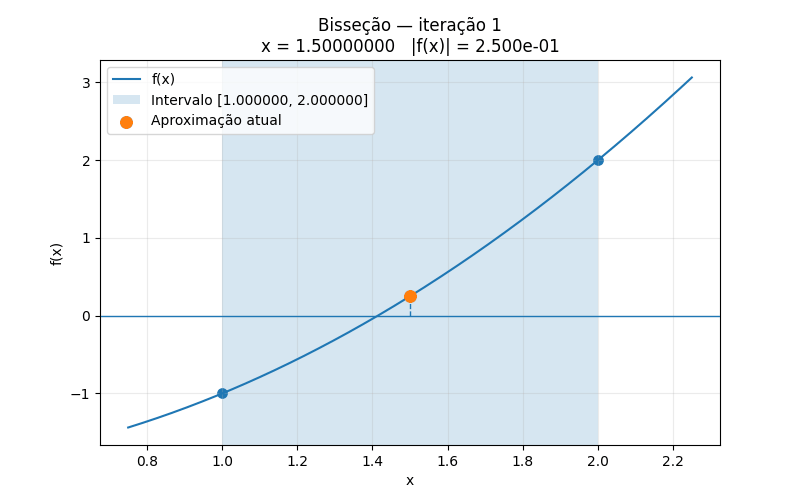

In [9]:
def animacao_bissecao(f, a, b, nome_arquivo="bissecao_f1.gif",
                      tol=TOL, max_iter=MAX_ITER):
    r = bissecao(f, a, b, tol, max_iter)
    intervalos = r["intervalos"]
    aproximacoes = r["aproximacoes"]

    margem = 0.25 * (b - a)
    xs = np.linspace(a - margem, b + margem, 500)
    ys = f(xs)

    fig, ax = plt.subplots(figsize=(8, 5))

    def atualizar(i):
        ax.clear()
        ai, bi = intervalos[i]
        ci = aproximacoes[i]

        ax.plot(xs, ys, label="f(x)")
        ax.axhline(0, linewidth=1)
        ax.axvspan(ai, bi, alpha=0.18, label=f"Intervalo [{ai:.6f}, {bi:.6f}]")
        ax.scatter([ai, bi], [f(ai), f(bi)], s=45)
        ax.scatter([ci], [f(ci)], s=70, zorder=5, label="Aproximação atual")
        ax.vlines(ci, 0, f(ci), linestyles="--", linewidth=1)

        ax.set_title(
            f"Bisseção — iteração {i+1}\n"
            f"x = {ci:.8f}   |f(x)| = {abs(f(ci)):.3e}"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")

    anim = FuncAnimation(fig, atualizar, frames=len(aproximacoes),
                         interval=650, repeat=False)
    anim.save(nome_arquivo, writer=PillowWriter(fps=2))
    plt.close(fig)

    return nome_arquivo

gif_bissecao = animacao_bissecao(f1, 1, 2)
display(Image(filename=gif_bissecao))

## Animação 2 — Método de Newton

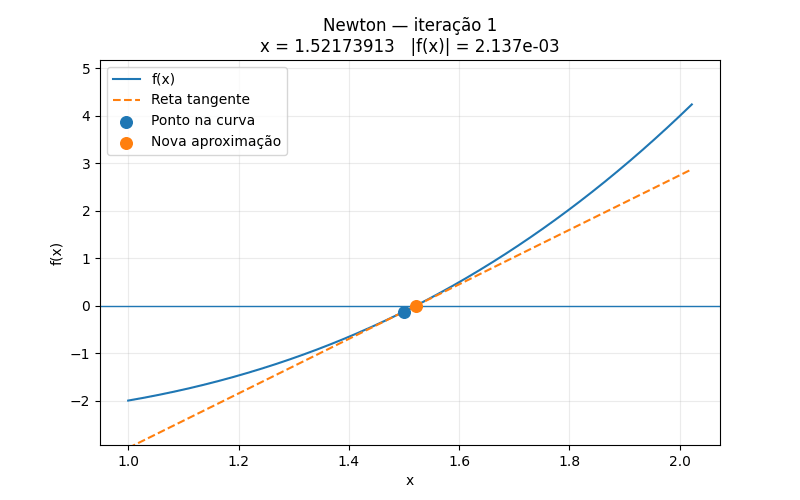

In [10]:
def animacao_newton(f, df, x0, nome_arquivo="newton_f2.gif",
                    tol=TOL, max_iter=MAX_ITER):
    r = newton(f, df, x0, tol, max_iter)
    aprox = r["aproximacoes"]

    xmin = min(aprox) - 0.5
    xmax = max(aprox) + 0.5
    xs = np.linspace(xmin, xmax, 500)
    ys = f(xs)

    fig, ax = plt.subplots(figsize=(8, 5))

    def atualizar(i):
        ax.clear()

        xk = aprox[i]
        xnovo = aprox[i + 1]

        ax.plot(xs, ys, label="f(x)")
        ax.axhline(0, linewidth=1)

        # Tangente usada para obter x_{k+1}.
        xt = np.linspace(xmin, xmax, 300)
        tangente = f(xk) + df(xk) * (xt - xk)
        ax.plot(xt, tangente, "--", label="Reta tangente")

        ax.scatter([xk], [f(xk)], s=70, zorder=5, label="Ponto na curva")
        ax.scatter([xnovo], [0], s=70, zorder=5, label="Nova aproximação")
        ax.vlines(xk, 0, f(xk), linestyles=":", linewidth=1)

        ax.set_title(
            f"Newton — iteração {i+1}\n"
            f"x = {xnovo:.8f}   |f(x)| = {abs(f(xnovo)):.3e}"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")

        # Evita que a tangente force uma escala vertical pouco útil.
        y_min = min(np.min(ys), 0)
        y_max = max(np.max(ys), 0)
        folga = 0.15 * max(y_max - y_min, 1)
        ax.set_ylim(y_min - folga, y_max + folga)

    anim = FuncAnimation(fig, atualizar, frames=len(aprox) - 1,
                         interval=800, repeat=False)
    anim.save(nome_arquivo, writer=PillowWriter(fps=1.5))
    plt.close(fig)

    return nome_arquivo

gif_newton = animacao_newton(f2, df2, 1.5)
display(Image(filename=gif_newton))

## Animação 3 — Método da secante

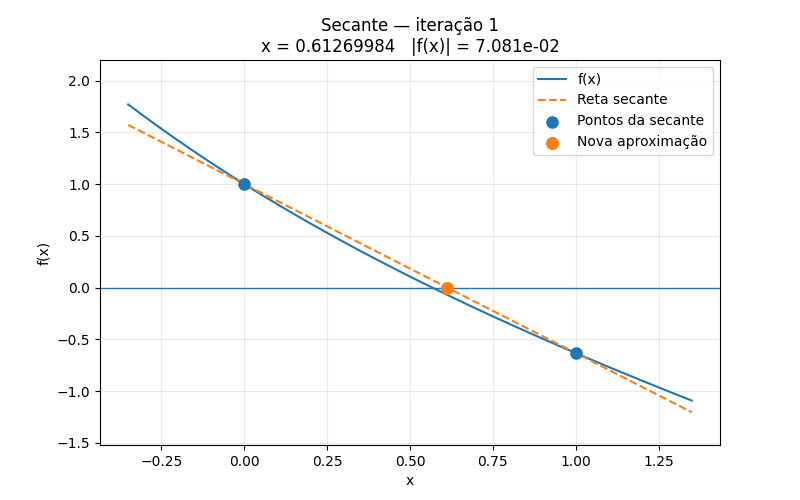

In [11]:
def animacao_secante(f, x0, x1, nome_arquivo="secante_f3.gif",
                     tol=TOL, max_iter=MAX_ITER):
    r = secante(f, x0, x1, tol, max_iter)
    aprox = r["aproximacoes"]

    xmin = min(aprox) - 0.35
    xmax = max(aprox) + 0.35
    xs = np.linspace(xmin, xmax, 500)
    ys = f(xs)

    fig, ax = plt.subplots(figsize=(8, 5))

    def atualizar(i):
        ax.clear()

        xa = aprox[i]
        xb = aprox[i + 1]
        xn = aprox[i + 2]

        ax.plot(xs, ys, label="f(x)")
        ax.axhline(0, linewidth=1)

        # Reta secante pelos dois pontos usados no passo atual.
        m = (f(xb) - f(xa)) / (xb - xa)
        xr = np.linspace(xmin, xmax, 300)
        yr = f(xa) + m * (xr - xa)
        ax.plot(xr, yr, "--", label="Reta secante")

        ax.scatter([xa, xb], [f(xa), f(xb)], s=65, zorder=5,
                   label="Pontos da secante")
        ax.scatter([xn], [0], s=70, zorder=5, label="Nova aproximação")

        ax.set_title(
            f"Secante — iteração {i+1}\n"
            f"x = {xn:.8f}   |f(x)| = {abs(f(xn)):.3e}"
        )
        ax.set_xlabel("x")
        ax.set_ylabel("f(x)")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")

        y_min = min(np.min(ys), 0)
        y_max = max(np.max(ys), 0)
        folga = 0.15 * max(y_max - y_min, 1)
        ax.set_ylim(y_min - folga, y_max + folga)

    anim = FuncAnimation(fig, atualizar, frames=len(aprox) - 2,
                         interval=800, repeat=False)
    anim.save(nome_arquivo, writer=PillowWriter(fps=1.5))
    plt.close(fig)

    return nome_arquivo

gif_secante = animacao_secante(f3, 0, 1)
display(Image(filename=gif_secante))

## Arquivos gerados

In [ ]:
print("GIFs gerados:")
print("1.", gif_bissecao)
print("2.", gif_newton)
print("3.", gif_secante)

print("\nTabela final:")
display(tabela_exibicao)

# Conclusão

A atividade implementou e comparou três métodos numéricos para determinação de raízes.

A bisseção reduziu sucessivamente intervalos contendo mudança de sinal. O método de Newton utilizou retas tangentes e a derivada da função. O método da secante substituiu a derivada por retas construídas a partir de duas aproximações.

Com os valores iniciais sugeridos, os métodos convergiram para as raízes das quatro funções analisadas. As animações permitem observar geometricamente como cada processo iterativo produz novas aproximações.

O notebook também foi estruturado de modo que seja possível alterar as funções, os valores iniciais, a tolerância e o número máximo de iterações sem reescrever os métodos.